### study on changeforest

https://pypi.org/project/changeforest/0.4.0/

In [17]:
import numpy as np

Sigma = np.full((5, 5), 0.7)
np.fill_diagonal(Sigma, 1)

rng = np.random.default_rng(12)
X = np.concatenate(
    (
        rng.normal(0, 1, (200, 5)),
        rng.multivariate_normal(np.zeros(5), Sigma, 200, method="cholesky"),
        rng.normal(0, 1, (200, 5)),
    ),
    axis=0,
)

In [11]:
from changeforest import changeforest

result = changeforest(X, "random_forest", "bs")
display(result)

result.split_points()

                    best_split max_gain p_value
(0, 600]                   400   14.814   0.005
 ¦--(0, 400]               200   59.314   0.005
 ¦   ¦--(0, 200]             6    -1.95    0.67
 ¦   °--(200, 400]         393   -8.668    0.81
 °--(400, 600]             412   -9.047    0.66

[200, 400]

/var/folders/sn/yb8rlqy521b7b_qpbwl8q8sw0000gn/T/ipykernel_21247/1617723772.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  result.plot().show()


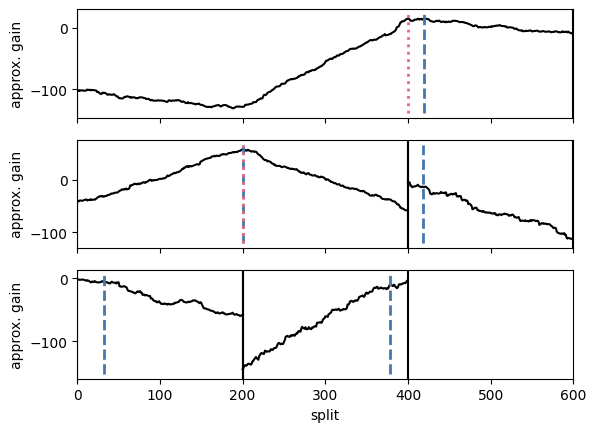

In [13]:
result.plot().show()

/var/folders/sn/yb8rlqy521b7b_qpbwl8q8sw0000gn/T/ipykernel_21247/1320020221.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  result.optimizer_result.plot().show()


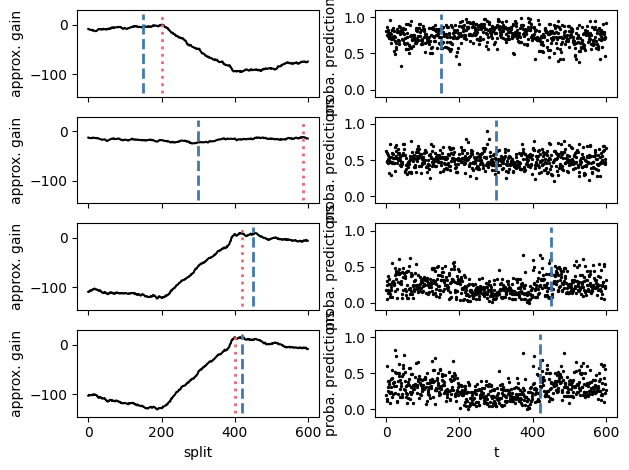

In [14]:
result.optimizer_result.plot().show()


In [15]:
from changeforest import Control
changeforest(X, "random_forest", "bs", Control(random_forest_n_estimators=50))

                    best_split max_gain p_value
(0, 600]                   416    7.463    0.01
 ¦--(0, 416]               200   43.935   0.005
 ¦   ¦--(0, 200]           193  -14.993   0.945
 ¦   °--(200, 416]         217    -9.13   0.085
 °--(416, 600]             591   -12.07       1

In [16]:
changeforest(X, "change_in_mean", "bs")

          best_split max_gain p_value
(0, 600]         589    8.625        